# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [5]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

subscriptions = pd.read_csv('./ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('./ravenstack_feature_usage.csv')

print(subscriptions.shape, feature_usage.shape)
display(subscriptions.head())
display(feature_usage.head())

print(subscriptions.dtypes)
print(feature_usage.dtypes)

print(subscriptions.isnull().sum().sum())
print(feature_usage.isnull().sum().sum())

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

usage_with_sub = feature_usage.merge(
    subscriptions[['subscription_id', 'start_date', 'end_date']],
    on='subscription_id',
    how='left'
)

before_start = (usage_with_sub['usage_date'] < usage_with_sub['start_date']).sum()
after_end = (usage_with_sub['end_date'].notna() &
             (usage_with_sub['usage_date'] > usage_with_sub['end_date']))
print(f'구독 시작 전 기록 {before_start}')
print(f'구독 종료 후 기록: {after_end}')

valid_mask = (
    (usage_with_sub['usage_date'] >= usage_with_sub['start_date']) &
    (usage_with_sub['end_date'].isna() | (usage_with_sub['usage_date'] <= usage_with_sub['end_date']))
)
valid_usage = usage_with_sub[valid_mask].copy()
print(f'유효 기능 사용: {len(valid_usage)} {len(usage_with_sub)}')

(5000, 14) (25000, 8)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


subscription_id        str
account_id             str
start_date             str
end_date               str
plan_tier              str
seats                int64
mrr_amount           int64
arr_amount           int64
is_trial              bool
upgrade_flag          bool
downgrade_flag        bool
churn_flag            bool
billing_frequency      str
auto_renew_flag       bool
dtype: object
usage_id                 str
subscription_id          str
usage_date               str
feature_name             str
usage_count            int64
usage_duration_secs    int64
error_count            int64
is_beta_feature         bool
dtype: object
4514
0
구독 시작 전 기록 19142
구독 종료 후 기록: 0        False
1        False
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Length: 25000, dtype: bool
유효 기능 사용: 5568 25000


---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?

#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

month_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2024-01-01,100.0,15.07,16.44,19.18,20.55,16.44,19.18
2024-02-01,100.0,21.35,16.85,15.73,7.87,23.60,28.09
2024-03-01,100.0,22.43,22.43,20.56,19.63,10.28,21.50
2024-04-01,100.0,17.92,27.36,19.81,19.81,16.04,15.09
2024-05-01,100.0,18.25,19.71,16.79,21.17,19.71,15.33
2024-06-01,100.0,28.00,12.00,16.00,20.00,15.33,21.33


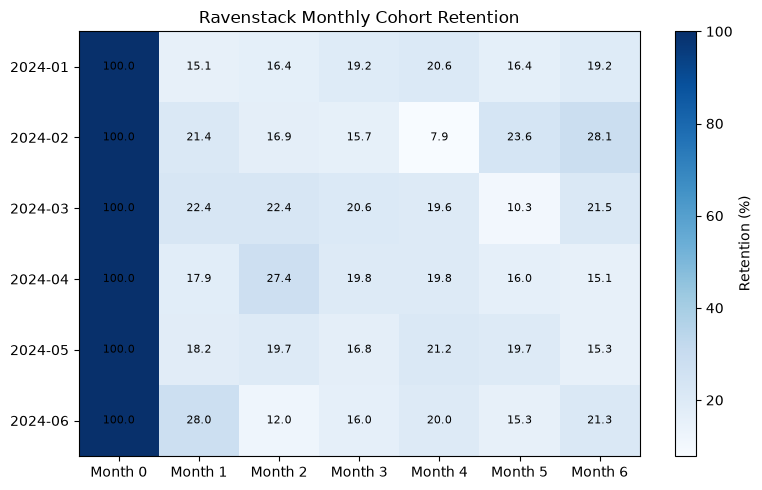

Month1 최고: 2024-06 28.00%
Month1 최저: 2024-01 15.07%


In [9]:
# 필수 1 코드를 작성하세요.
valid_usage['activity_month'] = valid_usage['usage_date'].values.astype('datetime64[M]')

cohort_month = valid_usage.groupby('subscription_id')['activity_month'].min().rename('cohort_month')
valid_usage = valid_usage.merge(cohort_month, on='subscription_id')

valid_usage["month_index"] = (
    (valid_usage["activity_month"].dt.year - valid_usage["cohort_month"].dt.year) * 12
    + (valid_usage["activity_month"].dt.month - valid_usage["cohort_month"].dt.month)
)

cohort_sizes = valid_usage.drop_duplicates('subscription_id').groupby('cohort_month')['subscription_id'].nunique()

pivot_counts = valid_usage.groupby(['cohort_month', 'month_index'])['subscription_id'].nunique().unstack(fill_value = 0)

retention_table = pivot_counts.div(cohort_sizes, axis=0)


sel = retention_table.loc["2024-01-01":"2024-06-01"].reindex(columns=range(0, 7))
sel_pct = (sel * 100).round(2)
display(sel_pct)


plt.figure(figsize=(8, 5))
plt.imshow(sel_pct, cmap="Blues", aspect="auto")
plt.colorbar(label="Retention (%)")
plt.xticks(range(7), [f"Month {i}" for i in range(7)])
plt.yticks(range(len(sel_pct)), sel_pct.index.strftime("%Y-%m"))
for i in range(sel_pct.shape[0]):
    for j in range(sel_pct.shape[1]):
        plt.text(j, i, f"{sel_pct.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
plt.title("Ravenstack Monthly Cohort Retention")
plt.tight_layout()
plt.show()

m1 = sel_pct[1]
print("Month1 최고:", m1.idxmax().strftime("%Y-%m"), f"{m1.max():.2f}%")
print("Month1 최저:", m1.idxmin().strftime("%Y-%m"), f"{m1.min():.2f}%")

### 필수 1 답변 작성란

- **Q1.** 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 이번 분석 질문이 가입이 아닌 제품기능을 처음 사용한 구독이 이후에도 다시 사용하는가이기 때문
- **Q2.** Month 0은 정의상 각 구독이 처음 기능을 사용한 달 그 자체이므로, 코호트에 속한 모든 구독이 그 달에 최소 1회 사용 기록을 갖는다 (따라서 항상 100%)
- **Q3.** Month 1 리텐션 최고 = 2024-06 (28.00%), 최저 = 2024-01 (15.07%)
- **Q4.** 네, 가능합니다. 2024-01 코호트는 Month4(20.55%) → Month5(16.44%)로 하락했다가 Month6(19.18%)로 다시 상승했습니다. 리텐션은 매달 꾸준히 감소하는 게 아니라 등락을 반복할 수 있습니다.

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

In [11]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

plan_tier
Basic         18.83
Pro           21.92
Enterprise    22.73
Name: subscription_id, dtype: float64


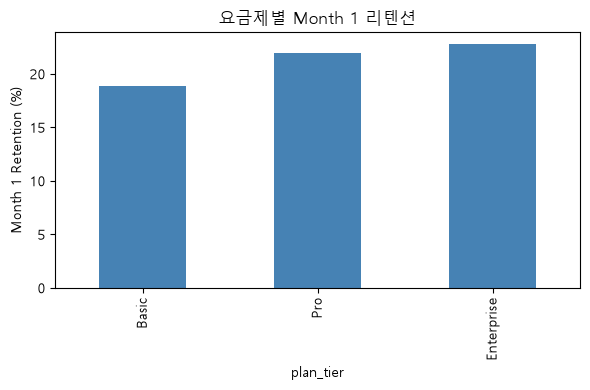

In [12]:
# 필수 2 코드를 작성하세요.
cohort_base = subscriptions[["subscription_id", "plan_tier"]].merge(
    cohort_month, on="subscription_id", how="inner"
)

selected_base = cohort_base[
    (cohort_base["cohort_month"] >= "2024-01-01") & (cohort_base["cohort_month"] <= "2024-06-01")
].copy()

plan_cohort_size = selected_base.groupby("plan_tier")["subscription_id"].nunique()

month1_subs = valid_usage.loc[valid_usage["month_index"] == 1, ["subscription_id"]].drop_duplicates()
month1_subs = month1_subs.merge(selected_base, on="subscription_id")
plan_month1 = month1_subs.groupby("plan_tier")["subscription_id"].nunique()

plan_retention = (plan_month1 / plan_cohort_size).sort_values()

plan_retention_pct = (plan_retention * 100).round(2)
print(plan_retention_pct)

plan_retention_pct.plot(kind="bar", color="steelblue", figsize=(6, 4))
plt.ylabel("Month 1 Retention (%)")
plt.title("요금제별 Month 1 리텐션")
plt.tight_layout()
plt.show()

### 필수 2 답변 작성란

- **Q1.** plan_tier는 요금제를 기준으로 나누는 속성 기반 세그멘테이션 기준
- **Q2.** Month1 리텐션이 가장 낮은 요금제는 Basic
- **Q3.** 전체 리텐션만 보면 특정 요금제의 취약점이 평균에 묻혀 안보임. 요금제별로 나누면 Basic처럼 상대적으로 취약한 그룹을 구체적으로 특정해 우선순위를 정할 수 있음.
- **Q4.** 아니요. 요금제 간 차이만으로 요금제 자체가 원인이라 단정할 수 없음. 베이직 고객군의 다른 요인이 섞여 있을 수 있어 추가 데이터 확인이 필요함.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

cohort_month
2024-01-01    11
2024-02-01    10
2024-03-01     9
2024-04-01     8
2024-05-01     7
2024-06-01     6
Name: months_since, dtype: int32


retention_m1  retention_m2  retention_m3
cohort_month billing_frequency                                          
2024-01-01   annual                    13.04         15.22         21.74
             monthly                   18.52         18.52         14.81
2024-02-01   annual                    25.64         12.82         10.26
             monthly                   18.00         20.00         20.00
2024-03-01   annual                    20.00         20.00         20.00
             monthly                   25.00         25.00         21.15
2024-04-01   annual                    16.33         26.53         16.33
             monthly                   19.30         28.07         22.81
2024-05-01   annual                    22.06         20.59         16.18
             monthly                   14.49         18.84         17.39
2024-06-01   annual                    29.85         13.43         19.40
             monthly                   26.51         10.84         13.25

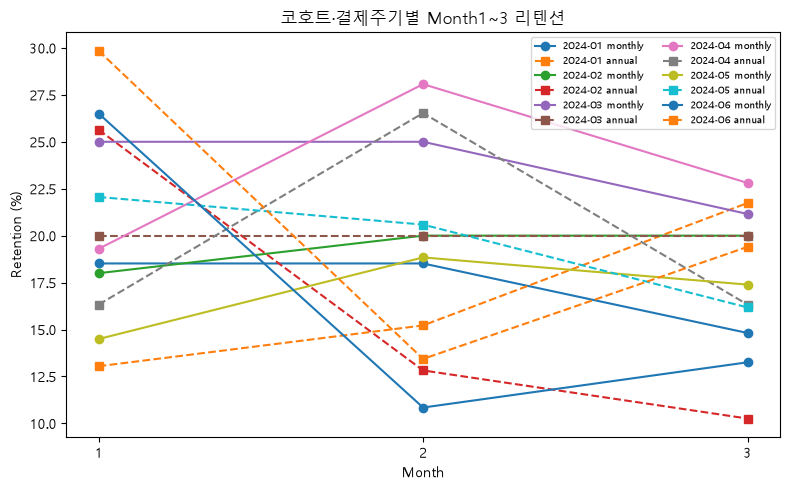

In [13]:
# 과제 1 코드를 작성하세요.
cohort_base2 = subscriptions[["subscription_id", "billing_frequency"]].merge(
    cohort_month, on="subscription_id", how="inner"
)

selected_base2 = cohort_base2[
    (cohort_base2["cohort_month"] >= "2024-01-01") & (cohort_base2["cohort_month"] <= "2024-06-01")
].copy()

max_date = feature_usage["usage_date"].max()  
selected_base2["months_since"] = (
    (max_date.year - selected_base2["cohort_month"].dt.year) * 12
    + (max_date.month - selected_base2["cohort_month"].dt.month)
)
print(selected_base2.groupby("cohort_month")["months_since"].first())

first_counts = selected_base2.groupby(["cohort_month", "billing_frequency"])["subscription_id"].nunique().rename("first_count")

month_counts = {}
for m in [1, 2, 3]:
    m_subs = valid_usage.loc[valid_usage["month_index"] == m, ["subscription_id"]].drop_duplicates()
    m_subs = m_subs.merge(selected_base2, on="subscription_id")
    month_counts[m] = m_subs.groupby(["cohort_month", "billing_frequency"])["subscription_id"].nunique().rename(f"month_{m}_count")

billing_retention = pd.concat([first_counts] + list(month_counts.values()), axis=1).fillna(0)

for m in [1, 2, 3]:
    billing_retention[f"retention_m{m}"] = billing_retention[f"month_{m}_count"] / billing_retention["first_count"] * 100

table = billing_retention[["retention_m1", "retention_m2", "retention_m3"]].round(2)
display(table)

piv = billing_retention.reset_index().pivot(index="cohort_month", columns="billing_frequency",
                                             values=["retention_m1", "retention_m2", "retention_m3"])
fig, ax = plt.subplots(figsize=(8, 5))
for freq in ["monthly", "annual"]:
    vals = [piv[f"retention_m{m}"][freq] for m in [1, 2, 3]]  
for cohort in piv.index:
    ax.plot([1, 2, 3], [piv["retention_m1"]["monthly"][cohort], piv["retention_m2"]["monthly"][cohort], piv["retention_m3"]["monthly"][cohort]],
            marker="o", linestyle="-", label=f"{cohort.strftime('%Y-%m')} monthly")
    ax.plot([1, 2, 3], [piv["retention_m1"]["annual"][cohort], piv["retention_m2"]["annual"][cohort], piv["retention_m3"]["annual"][cohort]],
            marker="s", linestyle="--", label=f"{cohort.strftime('%Y-%m')} annual")
ax.set_xticks([1, 2, 3]); ax.set_xlabel("Month"); ax.set_ylabel("Retention (%)")
ax.legend(fontsize=7, ncol=2)
plt.title("코호트/결제주기별 Month1~3 리텐션")
plt.tight_layout()
plt.show()

### 과제 1 답변 작성란

- **Q1.** 코호트별로 더 낮은 결제 주기가 계속 바뀜. 2024-01·03·04월은 annual이 더 낮고, 2024-02·05·06월은 monthly가 더 낮음. 차이는 작게는 −2.97%p, 크게는 +7.64%p까지 다양함.
- **Q2.** 변화폭도 코호트마다 방향이 제각각. 특히 2024-06 코호트는 annual,monthly 모두 Month1→2에 각각 −16.42%p, −15.66%p로 크게 하락했음. 전반적으로 꾸준한 감소가 아니라 코호트마다 등락을 반복하는 패턴임.
- **Q3.** 우선 점검 대상은 2024-06월 코호트. annual·monthly 두 결제 주기 모두 Month1→2에 동시에 큰 폭 하락했다는 건, 결제 주기 차이보다는 그 시점(약 7~8월경)에 공통으로 영향을 준 요인이 있었을 가능성을 알 수 있음. 단정하지 않고 해당 시기의 기능 변경 이력 등의 요인을 확인해봐야 함.
- **Q4.** 아니요. 코호트별로 결제 주기 우위가 뒤바뀌는 것 자체가 결제 주기 하나로는 설명이 안 된다는 신호. 표본도 코호트당 27~83건으로 크지 않아 우연에 의한 변동 가능성도 존재. 추가로 요금제,업종, 기능별 사용 로그 등의 여러 요인이 될만한 데이터를 추가로 확인해야 함.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?
2. 월간 N개월 리텐션은 어떻게 계산했나요?
3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?
4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?
5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?

1. 첫 유효 기능 사용 월을 코호트 출발점으로 사용했습니다.
2. 첫 유효 기능 사용 월로부터 N개월 뒤 재사용 구독 수 ÷ 해당 코호트 최초 구독 수로 계산했습니다.
3. 코호트(시작 시점)와 세그먼트(요금제·결제주기)를 함께 보면, 언제 시작했는가와 어떤 특성인가를 동시에 통제해 비교할 수 있어 특정 시점 문제인지 특정 그룹 문제인지 구분할 수 있습니다.
4. Basic 요금제가 상대적으로 낮았고, 결제 주기 기준으로는 코호트마다 방향이 달라 일관된 결론은 어려웠습니다.
5. 리텐션 차이는 상관관계일 뿐이며, 표본이 크지 않고 코호트마다 방향이 바뀌는 등 변동성이 커서, 실제 원인을 특정하려면 기능 사용 로그, 지원 티켓, 고객사 속성 등 추가 데이터 확인이 필요합니다.